#     Partie 1 – Exploration des données 

1) Charger les données CSV 

- Installation et Importation des bibliothèques nécessaire à la réalisation de cet atelier

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/smart_building_raw.csv")

2) Afficher les premières lignes du dataset ; 

In [6]:
df.head(5)

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


3) Afficher les dernières lignes du dataset ; 

In [7]:
df.tail(5)

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


4) Combien d'observations contient le dataset ? 

In [8]:
df.shape

(507, 14)

5) Combien de variables possède le dataset ? 

In [9]:
df.shape[1]
print("Le mombre de variables est de :" , df.shape[1])

Le mombre de variables est de : 14


6) Identifier les variables numériques ;

In [10]:
variables_numeriques = df.select_dtypes(include=np.number).columns
print("variables_numeriques : ", variables_numeriques)

variables_numeriques :  Index(['id_mesure', 'temperature', 'humidite', 'co2', 'occupation',
       'consommation_kwh'],
      dtype='str')


7) Identifier les variables catégorielles ; 

In [29]:
variables_categorielles = df.select_dtypes(include="object").columns.tolist()
print("variables_categorielles : ", variables_categorielles)

variables_categorielles :  ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


C:\Users\bmd\AppData\Local\Temp\ipykernel_11240\3403125477.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categorielles = df.select_dtypes(include="object").columns.tolist()


8) Identifier les dates 

In [12]:
variables_dates = df.select_dtypes(include=["datetime"]).columns

print("Variables de type date :", variables_dates)
# print(variables_dates)

Variables de type date : Index([], dtype='str')


9) Identifier les identifiants 

In [13]:
print(df.columns.tolist())


['id_mesure', 'date', 'batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


In [14]:
df.nunique()

id_mesure             500
date                  500
batiment                8
type_batiment          16
zone                    4
temperature           144
humidite              305
co2                   392
occupation            108
consommation_kwh      445
mode_climatisation      7
etat_systeme            3
jour_semaine            7
alerte                  2
dtype: int64

10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles. 

In [15]:
df.describe()

,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


11) Y a-t-il des variables potentiellement problématiques ?

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


Oui il existe des variables problematiques notamment pour les variables temperatures, humidite, cosommation et pour les occupations.

12) Pour les données incohérentes : 

a) rechercher des valeurs telles que humidité < 0 ; 

In [17]:
df[df.humidite <0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


b) rechercher des valeurs telles que humidité > 100 ;

In [18]:
df[df.humidite >100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


c) rechercher des valeurs telles que température extrêmement élevée ; 

- Affichons d'abord la colonne de temperatures

- Affichons maintenant les valeurs extremes de temperatures

In [19]:
df[df.temperature> 60]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05 00:00:00,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15 00:00:00,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16 00:00:00,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
499,1021,2025-01-06 00:00:00,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


d) rechercher des valeurs telles que occupation négative

In [20]:
df[df["occupation"] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
22,1031,2025-01-08 12:00:00,B2,École,D,26.1,57.6,648.0,-5.0,170.0,Eco,Normal,Mercredi,Non
376,1231,2025-02-27 12:00:00,B7,Bureau,D,19.0,35.3,680.0,-8.0,167.9,Eco,Alerte,Jeudi,Non
430,1081,2025-01-21 00:00:00,B1,Bureau,B,23.5,44.1,541.0,-12.0,248.7,Boost,Normal,Mardi,Non
487,1131,2025-02-02 12:00:00,B1,entrepot,A,26.3,70.6,1519.0,-2.0,173.4,Normal,Panne,Dimanche,Oui
494,1331,2025-03-24 12:00:00,B5,Centre commercial,B,22.7,54.6,979.0,-20.0,178.6,Normal,Alerte,Lundi,Oui


e) rechercher des valeurs telles que consommation négative ; 

In [21]:
df[df.consommation_kwh <0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante

In [23]:
import numpy as np
df.loc[df["humidite"] < 0, "humidite"] = np.nan
df.loc[df["temperature"] < 0, "temperature"] = np.nan
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan
df.loc[df["occupation"] < 0, "occupation"] = np.nan

In [24]:
df[df.humidite <0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte


g) rechercher des valeurs telles que catégories mal orthographiées. 

In [45]:
var_cats = df.drop(columns=["date"]).select_dtypes(include=["object"]).columns.tolist()

C:\Users\bmd\AppData\Local\Temp\ipykernel_11240\2888929926.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  var_cats = df.drop(columns=["date"]).select_dtypes(include=["object"]).columns.tolist()


In [46]:
var_cats

['batiment',
 'type_batiment',
 'zone',
 'mode_climatisation',
 'etat_systeme',
 'jour_semaine',
 'alerte']

In [ ]:
for colonne in var_cats:
    print("\n", colonne)
    print(df[colonne].unique())
    


 batiment
<StringArray>
['B8', 'B7', 'B5', 'B6', 'B3', 'B4', 'B2', 'B1']
Length: 8, dtype: str

 type_batiment
<StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'ÉCOLE',             'ecole',            'BUREAU',
                 nan,             'Bureu',            'bureau',
       ' UNIVERSITÉ',          'hôpital ', 'centre commercial',
          ' Bureau ',          'entrepot']
Length: 17, dtype: str

 zone
<StringArray>
['A', 'D', 'B', 'C']
Length: 4, dtype: str

 mode_climatisation
<StringArray>
['Eco', 'Normal', 'Boost', nan, 'normal', 'BOOST', 'normale', 'Normal ']
Length: 8, dtype: str

 etat_systeme
<StringArray>
['Normal', 'Alerte', 'Panne']
Length: 3, dtype: str

 jour_semaine
<StringArray>
['Jeudi', 'Lundi', 'Dimanche', 'Vendredi', 'Mercredi', 'Mardi', 'Samedi', nan]
Length: 8, dtype: str

 alerte
<StringArray>
['Non', 'Oui']
Length: 2, dtype: str


h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse 

In [ ]:
df["type_batiment"] = df["type_batiment"].str.strip().str.lower()
df["type_batiment"].unique()

<StringArray>
[         'entrepôt',            'bureau', 'centre commercial',
        'université',           'hôpital',             'école',
             'ecole',                 nan,             'bureu',
          'entrepot']
Length: 10, dtype: str

In [49]:
df["jour_semaine"] = df["jour_semaine"].str.strip().str.lower()
df["jour_semaine"].unique()

<StringArray>
['jeudi', 'lundi', 'dimanche', 'vendredi', 'mercredi', 'mardi', 'samedi', nan]
Length: 8, dtype: str

In [51]:
df["etat_systeme"] = df["etat_systeme"].str.strip().str.lower()
df["etat_systeme"].unique()

<StringArray>
['normal', 'alerte', 'panne']
Length: 3, dtype: str

In [52]:
df["mode_climatisation"] = df["mode_climatisation"].str.strip().str.lower()
df["mode_climatisation"].unique()

<StringArray>
['eco', 'normal', 'boost', nan, 'normale']
Length: 5, dtype: str

In [53]:
df["alerte"] = df["alerte"].str.strip().str.lower()
df["alerte"].unique()

<StringArray>
['non', 'oui']
Length: 2, dtype: str

In [55]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,entrepôt,A,23.0,40.0,851.0,26.0,138.4,eco,normal,jeudi,non
1,1275,2025-03-10 12:00:00,B7,bureau,D,28.0,69.0,538.0,0.0,170.2,eco,normal,lundi,non
2,1493,2025-05-04 00:00:00,B5,centre commercial,B,19.5,52.3,1198.0,64.0,149.8,normal,normal,dimanche,oui
3,1073,2025-01-19 00:00:00,B6,université,D,20.0,58.4,1014.0,30.0,141.6,normal,normal,dimanche,non
4,1454,2025-04-24 06:00:00,B7,bureau,D,26.8,70.5,628.0,42.0,228.3,normal,normal,jeudi,non


13) Pour les valeurs manquantes : 

a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne 

In [60]:
Nombre_manquant = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean()*100).round(2)
}).sort_values("pct_missing", ascending=False)
print(Nombre_manquant)
print("Colonnes avec des NA:", df.isna().any(axis=1).mean()*100, "%")

                    n_missing  pct_missing
temperature                14         2.76
humidite                   14         2.76
occupation                 11         2.17
consommation_kwh            9         1.78
co2                         7         1.38
mode_climatisation          5         0.99
jour_semaine                5         0.99
type_batiment               4         0.79
id_mesure                   0         0.00
date                        0         0.00
zone                        0         0.00
batiment                    0         0.00
etat_systeme                0         0.00
alerte                      0         0.00
Colonnes avec des NA: 12.82051282051282 %


b) Quelle variable possède le plus de valeurs manquantes ? 

Il s'agit des variables temperature et humidite avec chacune d'elle 14 valeurs manquantes.

c) Quelle stratégie utiliser pour les valeurs manquantes ?

Nous pouvons utiliser la ,médiane ou la moyenne quand il s'agit de variables numériques. Pour une variable catégorielle on privilégie la mode

d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ? 

La suppression n'est pas nécessairement une bonne stratégie.Il faudra d'abord vérifier la proportion des valeurs manquantes dans le dataframe d'abord. 

e) Dans quels cas utiliser la moyenne ? 

La moyenne peut être intéressante lorsque :

- la variable est numérique ;
- la distribution est relativement symétrique ;
- les valeurs aberrantes ne sont pas trop importantes.

f) 
Quand préférer la médiane ? 

La médiane est généralement plus robuste aux valeurs extrêmes.

g) Comment traiter une variable catégorielle ? 

Pour une variable catégorielle, on peut utiliser le mode, la valeur la plus fréquente.

14) Pour les doublons 

a) Identifier les  

In [62]:
df.duplicated().sum()

np.int64(7)

b) Afficher les 

In [63]:
df[df.duplicated()]


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
362,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
434,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
464,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
498,1479,2025-04-30 12:00:00,B3,hôpital,B,23.9,68.9,644.0,27.0,162.5,normal,normal,mercredi,non


c) sont-ils réellement identiques ? 

In [64]:
df.duplicated(keep=False)
df[df.duplicated(keep=False)]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
27,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
56,1479,2025-04-30 12:00:00,B3,hôpital,B,23.9,68.9,644.0,27.0,162.5,normal,normal,mercredi,non
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
238,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
362,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


Oui ils sont identiques


d) supprimer les doublons réellement identifiés. 

In [65]:
df = df.drop_duplicates()

e) Vérifier la suppression 

In [66]:
df.duplicated().sum()

np.int64(0)

15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement :

a) Les distributions (symétrique ou non)

b) La dispersion 

c) Les valeurs extrêmes 

d) les valeurs potentiellement aberrantes 


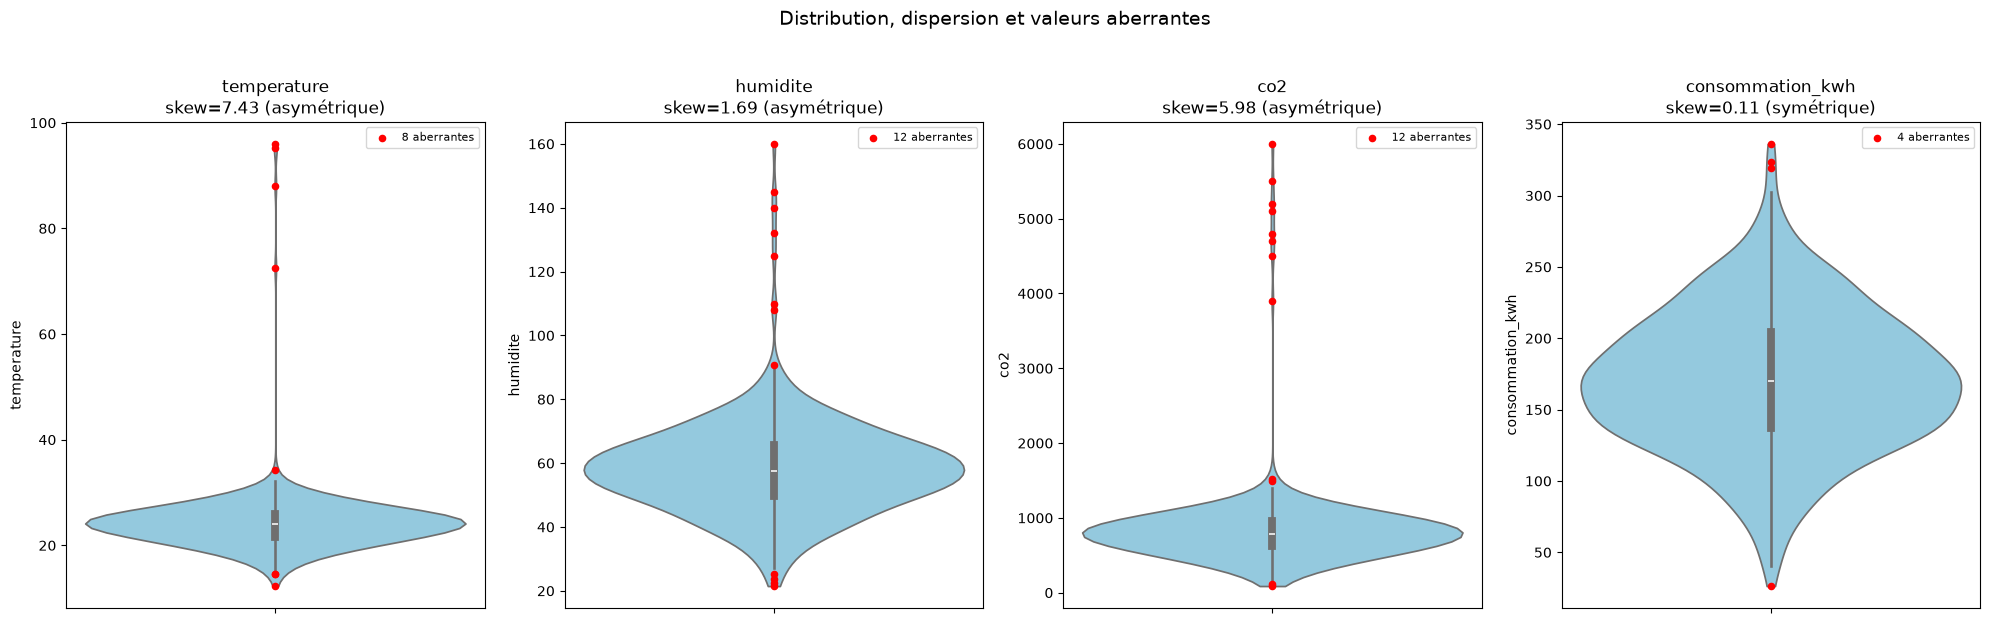

In [73]:
cols_to_plot = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    data = df[col].dropna()

    # Violin plot (distribution) + boxplot intégré (dispersion + outliers)
    sns.violinplot(y=data, ax=axes[i], inner="box", color="skyblue", cut=0)

    # Calcul des bornes IQR pour repérer les valeurs aberrantes
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = data[(data < low) | (data > high)]

    # On superpose les points aberrants en rouge pour les repérer clairement
    axes[i].scatter(
        [0] * len(outliers), outliers,
        color="red", s=20, zorder=5, label=f"{len(outliers)} aberrantes"
    )

    # Skewness pour quantifier la symétrie
    skew = data.skew()
    symetrie = "symétrique" if abs(skew) < 0.5 else "asymétrique"

    axes[i].set_title(f"{col}\nskew={skew:.2f} ({symetrie})")
    axes[i].legend(loc="upper right", fontsize=8)

plt.suptitle("Distribution, dispersion et valeurs aberrantes", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

16) Quelle stratégie utiliser pour les valeurs aberrantes ? 

Il ne faut pas automatiquement supprimer toutes les valeurs aberrantes.

Une valeur extrême peut être :

une erreur de capteur ;
une erreur de saisie ;
une véritable situation exceptionnelle.

Par exemple, une consommation très élevée peut correspondre à un bâtiment réellement très occupé.

La strategie peut dependre: on peut faire une :

- Correction : si l'erreur est identifiable (faute de frappe évidente), on corrige la valeur.
- Suppression : si la ligne est clairement erronée et non récupérable.
- Plafonnement (capping): on limite la valeur à un seuil raisonnable plutôt que de la supprimer entièrement.
- Conservation : si la valeur est extrême mais réelle et informative (ex. un très gros client), on la garde.



17) Afficher la fréquence des : 

a) bâtiments ; 

In [76]:
freq_bat = pd.DataFrame({
    "count": df["batiment"].value_counts(),
    "percent": (df["batiment"].value_counts(normalize=True) * 100).round(2)
})
freq_bat

,count,percent
batiment,,
B1,92,18.4
B5,65,13.0
B7,64,12.8
B2,60,12.0
B4,58,11.6
B3,57,11.4
B8,53,10.6
B6,51,10.2


b) types de bâtiments ; 

In [78]:
freq_typeBat= pd.DataFrame({
    "count": df["type_batiment"].value_counts(),
    "percent": (df["type_batiment"].value_counts(normalize=True) * 100).round(2)
})
freq_typeBat

,count,percent
type_batiment,,
bureau,210,42.34
centre commercial,65,13.10
école,59,11.90
hôpital,58,11.69
entrepôt,52,10.48
université,49,9.88
ecole,1,0.20
bureu,1,0.20
entrepot,1,0.20


c) modes de climatisation ;

In [79]:
freq= pd.DataFrame({
    "count": df["mode_climatisation"].value_counts(),
    "percent": (df["mode_climatisation"].value_counts(normalize=True) * 100).round(2)
})
freq_typeBat

,count,percent
type_batiment,,
bureau,210,42.34
centre commercial,65,13.10
école,59,11.90
hôpital,58,11.69
entrepôt,52,10.48
université,49,9.88
ecole,1,0.20
bureu,1,0.20
entrepot,1,0.20


d) états du système ; 

In [80]:
freq= pd.DataFrame({
    "count": df["etat_systeme"].value_counts(),
    "percent": (df["etat_systeme"].value_counts(normalize=True) * 100).round(2)
})
freq

,count,percent
etat_systeme,,
normal,436,87.2
alerte,52,10.4
panne,12,2.4


e) classes alerte. 

In [81]:
freq= pd.DataFrame({
    "count": df["alerte"].value_counts(),
    "percent": (df["alerte"].value_counts(normalize=True) * 100).round(2)
})
freq

,count,percent
alerte,,
non,356,71.2
oui,144,28.8


18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

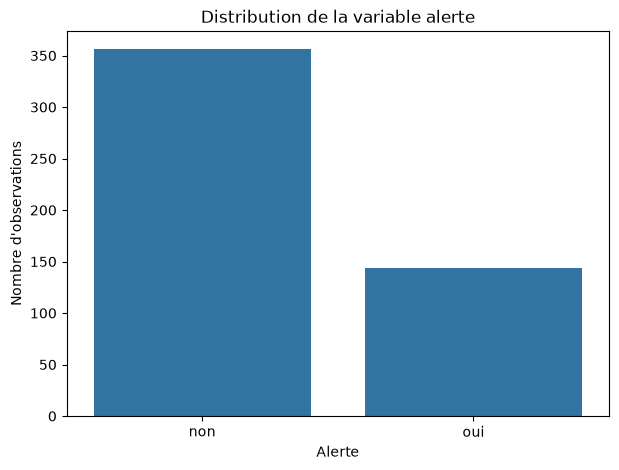

In [82]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="alerte"
)

plt.title("Distribution de la variable alerte")
plt.xlabel("Alerte")
plt.ylabel("Nombre d'observations")

plt.show()

Oui en effet il existe un desequilibre dans la classe alerte puisque la classe "Non" est plus representee.

19) Pour la corrélation sur les variables numériques :

a) visualiser avec seaborn, la matrice de corrélation. 

In [92]:
# 1. Enlever 'id_mesure' de la liste 
vars_clean = [col for col in variables_numeriques if col != 'id_mesure']

# 2. Calculer la corrélation
correlation = df[vars_clean].corr()### Selectionnons d'abord les variables numeriques

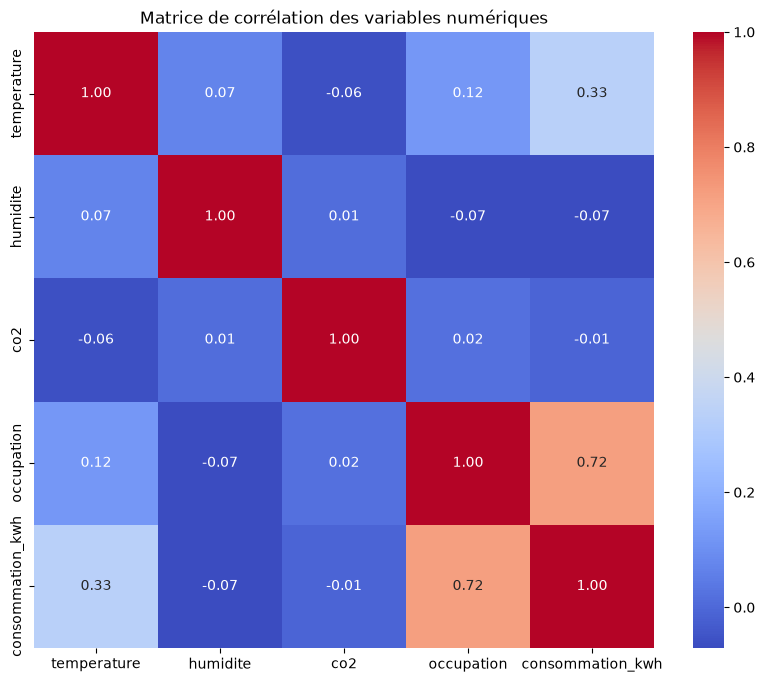

In [93]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

b) identifier les corrélations positives, négatives et les variables faiblement corrélées.

# Analyse de la matrice de corrélation des variables numériques

La matrice de corrélation de Pearson évalue les relations linéaires entre les 6 variables numériques du jeu de données (les coefficients varient de -1 à +1).


## 1. Variables cibles et corrélations majeures

* **Occupation et Consommation électrique (`occupation` / `consommation_kwh`) :**
  * **Corrélation forte et positive (r = 0,72) :** Il s'agit de la relation la plus significative du jeu de données. Une hausse du niveau d'occupation est directement liée à une augmentation de la consommation d'énergie.

* **Température et Consommation électrique (`temperature` / `consommation_kwh`) :**
  * **Corrélation positive modérée (r = 0,33) :** Une hausse de la température s'accompagne d'une augmentation modérée de la consommation (ex. utilisation de systèmes de climatisation ou de ventilation).

* **Température et Occupation (`temperature` / `occupation`) :**
  * **Corrélation positive faible (r = 0,12) :** Une légère tendance indique des températures mesurées légèrement plus élevées lorsque l'occupation augmente (dégagement thermique humain).

---

## 2. Variables peu ou pas corrélées

* **`co2` et `humidite` :**
  * Leurs coefficients de corrélation avec l'ensemble des autres variables sont quasi nuls (compris entre -0,07 et 0,02). Cela indique une absence de relation linéaire directe avec la consommation énergétique, la température ou l'occupation dans ce jeu de données.


